# 🧠 02_nlp_intent_classifier.ipynb — NLP Intent Classifier
## TextCNN · BiLSTM · DistilBERT (multilingual)

**الـ Intents (8 classes):**

| Intent | المعنى | أمثلة |
|--------|--------|-------|
| `wake` | تفعيل الروبوت | therapeia, hey robot, terapia |
| `start` | بدء الدوران | start, ready, let's go |
| `scan` | التقاط صورة وتصنيف | scan, take photo, identify |
| `stop` | إيقاف | stop, enough, done |
| `sleep` | وضع الخمول | sleep, go home, standby |
| `inventory` | عرض المخزون | inventory, report, what do you have |
| `quantity` | استفسار عن كمية | how many, count, quantity |
| `medicine_name` | اسم الدواء | brufen, ketofan, cataflam |

**الـ Output المحفوظ:**
- `models/intent_cnn.pt` — TextCNN (خفيف للـ Pi)
- `models/intent_lstm.pt` — BiLSTM
- `models/intent_bert/` — DistilBERT (أدق)
- `models/nlp_meta.json` — vocab + label map

## Cell 1 — تثبيت المكتبات

In [1]:
import subprocess, sys
for pkg in ['transformers', 'torch', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
print('All packages installed ✅')

All packages installed ✅


## Cell 2 — Imports

In [2]:
import os, re, json, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_scheduler,
)
from torch.optim import AdamW

os.makedirs('models', exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cpu
PyTorch : 2.6.0


## Cell 3 — تحميل البيانات

In [3]:
df = pd.read_csv('therapeia_intent_dataset_10k.csv')
print(f'Shape  : {df.shape}')
print(f'Intents: {sorted(df.intent.unique())}')
print()
print(df.intent.value_counts())

Shape  : (10000, 2)
Intents: ['inventory', 'medicine_name', 'quantity', 'scan', 'sleep', 'start', 'stop', 'wake']

intent
stop             1250
quantity         1250
inventory        1250
scan             1250
wake             1250
sleep            1250
medicine_name    1250
start            1250
Name: count, dtype: int64


## Cell 4 — Preprocessing & Split

In [4]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s'\u0600-\u06FF]", ' ', text)  # keep Arabic too
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean'] = df['text'].apply(clean_text)

le = LabelEncoder()
df['label'] = le.fit_transform(df['intent'])
INTENT_NAMES = list(le.classes_)
NUM_CLASSES  = len(INTENT_NAMES)
print('Classes:', INTENT_NAMES)
print('Total  :', NUM_CLASSES)

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    df['clean'].values, df['label'].values,
    test_size=0.30, stratify=df['label'], random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42,
)
print(f'Train:{len(X_train)}  Val:{len(X_val)}  Test:{len(X_test)}')

Classes: ['inventory', 'medicine_name', 'quantity', 'scan', 'sleep', 'start', 'stop', 'wake']
Total  : 8
Train:7000  Val:1500  Test:1500


## Cell 5 — Vocabulary (CNN & LSTM)

In [5]:
all_words = ' '.join(X_train).split()
vocab     = ['<PAD>', '<UNK>'] + sorted(set(all_words))
word2idx  = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
MAX_LEN    = 14

def encode(texts, max_len=MAX_LEN):
    out = []
    for t in texts:
        ids = [word2idx.get(w, 1) for w in t.split()][:max_len]
        ids += [0] * (max_len - len(ids))
        out.append(ids)
    return np.array(out, dtype=np.int64)

X_tr_enc  = encode(X_train)
X_val_enc = encode(X_val)
X_te_enc  = encode(X_test)

print(f'Vocab size : {VOCAB_SIZE}')
print(f'Max length : {MAX_LEN}')

Vocab size : 504
Max length : 14


## Cell 6 — PyTorch Dataset

In [6]:
class IntentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):           return len(self.y)
    def __getitem__(self, i):    return self.X[i], self.y[i]

BATCH = 16
train_dl = DataLoader(IntentDataset(X_tr_enc,  y_train), batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(IntentDataset(X_val_enc, y_val),   batch_size=BATCH)
test_dl  = DataLoader(IntentDataset(X_te_enc,  y_test),  batch_size=BATCH)

print(f'Train batches: {len(train_dl)} | Val: {len(val_dl)} | Test: {len(test_dl)}')

Train batches: 438 | Val: 94 | Test: 94


## Cell 7 — Model 1: TextCNN

In [7]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64,
                 num_classes=NUM_CLASSES,
                 num_filters=64, kernel_sizes=(2, 3, 4)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)  # (B, E, L)
        x = [torch.relu(c(x)).max(-1)[0] for c in self.convs]
        x = torch.cat(x, dim=1)
        x = self.dropout(x)
        return self.fc(x)

print('TextCNN defined ✅')

TextCNN defined ✅


## Cell 8 — Model 2: BiLSTM

In [8]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64,
                 hidden=128, num_layers=2,
                 num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden,
                                 num_layers=num_layers,
                                 batch_first=True,
                                 bidirectional=True,
                                 dropout=0.3)
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        x, _ = self.lstm(self.embedding(x))
        x     = x[:, -1, :]          # last timestep
        return self.fc(self.dropout(x))

print('BiLSTM defined ✅')

BiLSTM defined ✅


## Cell 9 — Training Helper

In [9]:
def train_model(model, train_dl, val_dl, epochs=25, lr=2e-3, patience=5):
    model.to(DEVICE)
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    best_val, no_improve = 0.0, 0

    for epoch in range(epochs):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct = 0.0, 0
        for X_b, y_b in train_dl:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            out  = model(X_b)
            loss = crit(out, y_b)
            loss.backward()
            opt.step()
            t_loss    += loss.item()
            t_correct += (out.argmax(1) == y_b).sum().item()

        # ── Val ──────────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in val_dl:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out   = model(X_b)
                v_loss    += crit(out, y_b).item()
                v_correct += (out.argmax(1) == y_b).sum().item()

        n_train, n_val = len(train_dl.dataset), len(val_dl.dataset)
        t_acc = t_correct / n_train
        v_acc = v_correct / n_val
        history['train_loss'].append(t_loss / len(train_dl))
        history['val_loss'].append(v_loss   / len(val_dl))
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if (epoch + 1) % 5 == 0:
            print(f'  Ep {epoch+1:02d}/{epochs} | '
                  f'train_acc={t_acc:.3f}  val_acc={v_acc:.3f}')

        # Early stopping
        if v_acc > best_val:
            best_val   = v_acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break

    return history


def evaluate_torch(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in dataloader:
            out   = model(X_b.to(DEVICE))
            preds += out.argmax(1).cpu().tolist()
            trues += y_b.tolist()
    return np.array(preds), np.array(trues)

print('Helpers defined ✅')

Helpers defined ✅


## Cell 10 — Train TextCNN

In [10]:
print('\n── TextCNN ──────────────────────────────────────────')
cnn_model   = TextCNN(VOCAB_SIZE)
cnn_history = train_model(cnn_model, train_dl, val_dl, epochs=30)

cnn_preds, cnn_true = evaluate_torch(cnn_model, test_dl)
cnn_acc = accuracy_score(cnn_true, cnn_preds)
print(f'\n  TextCNN Test Acc: {cnn_acc:.4f}')
print(classification_report(cnn_true, cnn_preds, target_names=INTENT_NAMES))


── TextCNN ──────────────────────────────────────────
  Ep 05/30 | train_acc=0.992  val_acc=0.990
  Ep 10/30 | train_acc=0.993  val_acc=0.989
  Early stop at epoch 12

  TextCNN Test Acc: 0.9907
               precision    recall  f1-score   support

    inventory       1.00      1.00      1.00       187
medicine_name       1.00      1.00      1.00       187
     quantity       1.00      1.00      1.00       188
         scan       1.00      1.00      1.00       188
        sleep       1.00      0.98      0.99       188
        start       0.99      0.95      0.97       187
         stop       0.98      1.00      0.99       188
         wake       0.95      0.99      0.97       187

     accuracy                           0.99      1500
    macro avg       0.99      0.99      0.99      1500
 weighted avg       0.99      0.99      0.99      1500



## Cell 11 — Train BiLSTM

In [11]:
print('\n── BiLSTM ───────────────────────────────────────────')
lstm_model   = BiLSTM(VOCAB_SIZE)
lstm_history = train_model(lstm_model, train_dl, val_dl, epochs=30)

lstm_preds, lstm_true = evaluate_torch(lstm_model, test_dl)
lstm_acc = accuracy_score(lstm_true, lstm_preds)
print(f'\n  BiLSTM Test Acc: {lstm_acc:.4f}')
print(classification_report(lstm_true, lstm_preds, target_names=INTENT_NAMES))


── BiLSTM ───────────────────────────────────────────
  Ep 05/30 | train_acc=0.978  val_acc=0.983
  Ep 10/30 | train_acc=0.989  val_acc=0.992
  Ep 15/30 | train_acc=0.986  val_acc=0.987
  Early stop at epoch 15

  BiLSTM Test Acc: 0.9920
               precision    recall  f1-score   support

    inventory       1.00      1.00      1.00       187
medicine_name       1.00      1.00      1.00       187
     quantity       1.00      1.00      1.00       188
         scan       0.98      1.00      0.99       188
        sleep       1.00      1.00      1.00       188
        start       0.97      0.96      0.97       187
         stop       1.00      0.99      1.00       188
         wake       0.98      0.98      0.98       187

     accuracy                           0.99      1500
    macro avg       0.99      0.99      0.99      1500
 weighted avg       0.99      0.99      0.99      1500



## Cell 12 — Train DistilBERT (multilingual)

In [13]:
# ── Tokenizer ─────────────────────────────────────────────────────────────────
# multilingual-cased يفهم العربي والإنجليزي
BERT_NAME = 'distilbert-base-multilingual-cased'
tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_NAME)

class BertIntentDataset(Dataset):
    def __init__(self, texts, labels, max_len=48):
        enc = tokenizer(
            list(texts), padding='max_length',
            truncation=True, max_length=max_len,
            return_tensors='pt',
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {
            'input_ids'     : self.input_ids[i],
            'attention_mask': self.attention_mask[i],
        }, self.labels[i]

bert_train_dl = DataLoader(BertIntentDataset(X_train, y_train), batch_size=16, shuffle=True)
bert_val_dl   = DataLoader(BertIntentDataset(X_val,   y_val),   batch_size=16)
bert_test_dl  = DataLoader(BertIntentDataset(X_test,  y_test),  batch_size=16)

# ── Model ─────────────────────────────────────────────────────────────────────
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True,
).to(DEVICE)

opt_bert   = AdamW(bert_model.parameters(), lr=3e-5)
BERT_EPOCHS = 6
scheduler  = get_scheduler(
    'linear', opt_bert,
    num_warmup_steps=len(bert_train_dl),
    num_training_steps=len(bert_train_dl) * BERT_EPOCHS,
)
criterion  = nn.CrossEntropyLoss()

bert_history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

print(f'Training DistilBERT ({BERT_EPOCHS} epochs)...')
for epoch in range(BERT_EPOCHS):
    # Train
    bert_model.train()
    t_loss, t_correct = 0.0, 0
    for batch, labels_b in bert_train_dl:
        batch    = {k: v.to(DEVICE) for k, v in batch.items()}
        labels_b = labels_b.to(DEVICE)
        opt_bert.zero_grad()
        out  = bert_model(**batch).logits
        loss = criterion(out, labels_b)
        loss.backward()
        opt_bert.step()
        scheduler.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels_b).sum().item()

    # Val
    bert_model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for batch, labels_b in bert_val_dl:
            batch    = {k: v.to(DEVICE) for k, v in batch.items()}
            labels_b = labels_b.to(DEVICE)
            out      = bert_model(**batch).logits
            v_loss    += criterion(out, labels_b).item()
            v_correct += (out.argmax(1) == labels_b).sum().item()

    t_acc = t_correct / len(bert_train_dl.dataset)
    v_acc = v_correct / len(bert_val_dl.dataset)
    bert_history['train_acc'].append(t_acc)
    bert_history['val_acc'].append(v_acc)
    bert_history['train_loss'].append(t_loss / len(bert_train_dl))
    bert_history['val_loss'].append(v_loss   / len(bert_val_dl))
    print(f'  Ep {epoch+1}/{BERT_EPOCHS} | train_acc={t_acc:.3f}  val_acc={v_acc:.3f}')

# ── Test ──────────────────────────────────────────────────────────────────────
bert_model.eval()
bert_preds, bert_true = [], []
with torch.no_grad():
    for batch, labels_b in bert_test_dl:
        batch    = {k: v.to(DEVICE) for k, v in batch.items()}
        out      = bert_model(**batch).logits
        bert_preds += out.argmax(1).cpu().tolist()
        bert_true  += labels_b.tolist()

bert_preds = np.array(bert_preds)
bert_true  = np.array(bert_true)
bert_acc   = accuracy_score(bert_true, bert_preds)
print(f'\n  DistilBERT Test Acc: {bert_acc:.4f}')
print(classification_report(bert_true, bert_preds, target_names=INTENT_NAMES))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DistilBERT (6 epochs)...
  Ep 1/6 | train_acc=0.619  val_acc=0.977
  Ep 2/6 | train_acc=0.989  val_acc=0.990
  Ep 3/6 | train_acc=0.991  val_acc=0.990
  Ep 4/6 | train_acc=0.992  val_acc=0.990
  Ep 5/6 | train_acc=0.994  val_acc=0.990
  Ep 6/6 | train_acc=0.994  val_acc=0.990

  DistilBERT Test Acc: 0.9953
               precision    recall  f1-score   support

    inventory       1.00      1.00      1.00       187
medicine_name       1.00      1.00      1.00       187
     quantity       1.00      1.00      1.00       188
         scan       1.00      1.00      1.00       188
        sleep       1.00      1.00      1.00       188
        start       0.99      0.97      0.98       187
         stop       1.00      1.00      1.00       188
         wake       0.97      0.99      0.98       187

     accuracy                           1.00      1500
    macro avg       1.00      1.00      1.00      1500
 weighted avg       1.00      1.00      1.00      1500



## Cell 13 — Model Comparison Dashboard

════════════════════════════════════════════════
   NLP MODEL COMPARISON — Therapeía
════════════════════════════════════════════════
  DistilBERT  : 0.9953  █████████████████████████████
  BiLSTM      : 0.9920  █████████████████████████████
  TextCNN     : 0.9907  █████████████████████████████

  🏆 Best: DistilBERT (0.9953)
════════════════════════════════════════════════


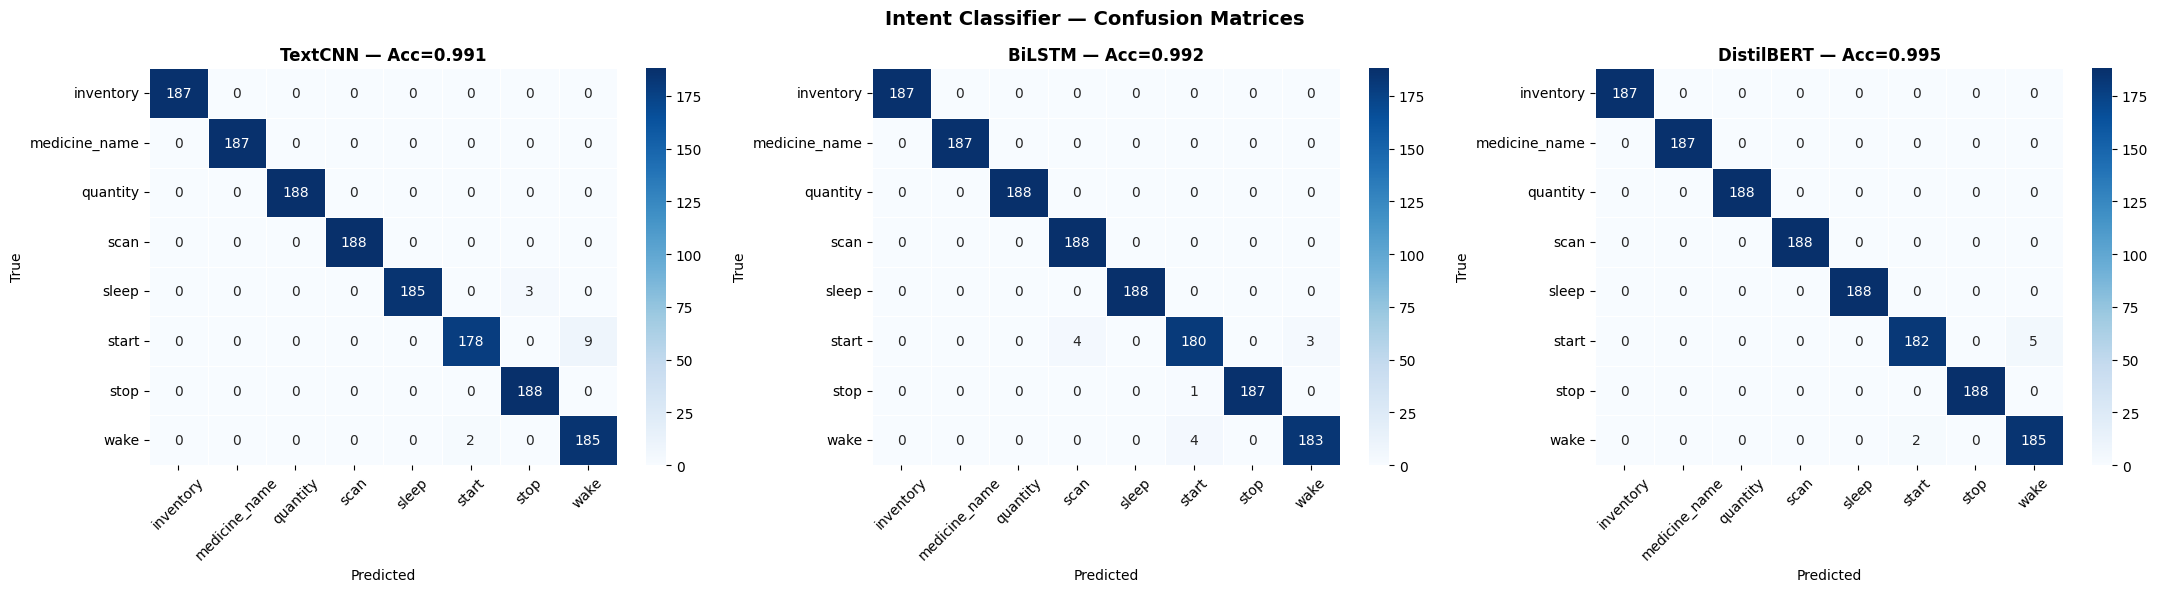

In [14]:
results = {
    'TextCNN'   : (cnn_acc,  cnn_preds,  cnn_true,  cnn_history),
    'BiLSTM'    : (lstm_acc, lstm_preds, lstm_true, lstm_history),
    'DistilBERT': (bert_acc, bert_preds, bert_true, bert_history),
}

print('═'*48)
print('   NLP MODEL COMPARISON — Therapeía')
print('═'*48)
for name, (acc, *_) in sorted(results.items(), key=lambda x: -x[1][0]):
    bar = '█' * int(acc * 30)
    print(f'  {name:<12}: {acc:.4f}  {bar}')

best_nlp_name = max(results, key=lambda k: results[k][0])
print(f'\n  🏆 Best: {best_nlp_name} ({results[best_nlp_name][0]:.4f})')
print('═'*48)

# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (name, (acc, preds, true, _)) in zip(axes, results.items()):
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=INTENT_NAMES, yticklabels=INTENT_NAMES, ax=ax,
                linewidths=0.5)
    ax.set_title(f'{name} — Acc={acc:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Intent Classifier — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('models/nlp_confusion_matrices.png', dpi=150)
plt.show()

## Cell 14 — حفظ الـ Models

In [15]:
import json

# ── NLP Meta  ─────────────────────────────────────────────────────────
nlp_meta = {
    'word2idx'    : word2idx,
    'intent_names': INTENT_NAMES,
    'max_len'     : MAX_LEN,
    'num_classes' : NUM_CLASSES,
    'best_model'  : best_nlp_name,
    'accuracies'  : {k: float(v[0]) for k, v in results.items()},
    'bert_name'   : BERT_NAME,
}
with open('models/nlp_meta.json', 'w') as f:
    json.dump(nlp_meta, f, indent=2, ensure_ascii=False)

# ── CNN ──────────────────────────────────────────────────────────────────────
torch.save(cnn_model.state_dict(),  'models/intent_cnn.pt')

# ── BiLSTM ───────────────────────────────────────────────────────────────────
torch.save(lstm_model.state_dict(), 'models/intent_lstm.pt')

# ── DistilBERT ───────────────────────────────────────────────────────────────
bert_model.save_pretrained('models/intent_bert')
tokenizer.save_pretrained('models/intent_bert')

print('All NLP models saved ✅')
print()
print('For Pi → TextCNN or BiLSTM (خفيف وسريع):')
print('  models/intent_cnn.pt')
print('  models/intent_lstm.pt')
print('  models/intent_bert/    (أدق لكن أبطأ)')
print('  models/nlp_meta.json')
print()
print('✅ جاهز للاستخدام في 03_voice_controller.ipynb')

All NLP models saved ✅

For Pi → TextCNN or BiLSTM (خفيف وسريع):
  models/intent_cnn.pt
  models/intent_lstm.pt
  models/intent_bert/    (أدق لكن أبطأ)
  models/nlp_meta.json

✅ جاهز للاستخدام في 03_voice_controller.ipynb


Shape  : (10000, 2)
Intents: ['inventory', 'medicine_name', 'quantity', 'scan', 'sleep', 'start', 'stop', 'wake']

intent
stop             1250
quantity         1250
inventory        1250
scan             1250
wake             1250
sleep            1250
medicine_name    1250
start            1250
Name: count, dtype: int64

                           text        intent
                   turn on asap          wake
                ممكن اقرأ الكود          scan
          capture image at once          scan
      hello robot are you there          wake
       عايز اعرف meloxicam الان medicine_name
                         go now         start
                 show all items     inventory
                 take a picture          scan
         get started right away         start
            attention right now          wake
يا روبوت لو سمحت صحى يا ثيرابيا          wake
                terapiya for me          wake


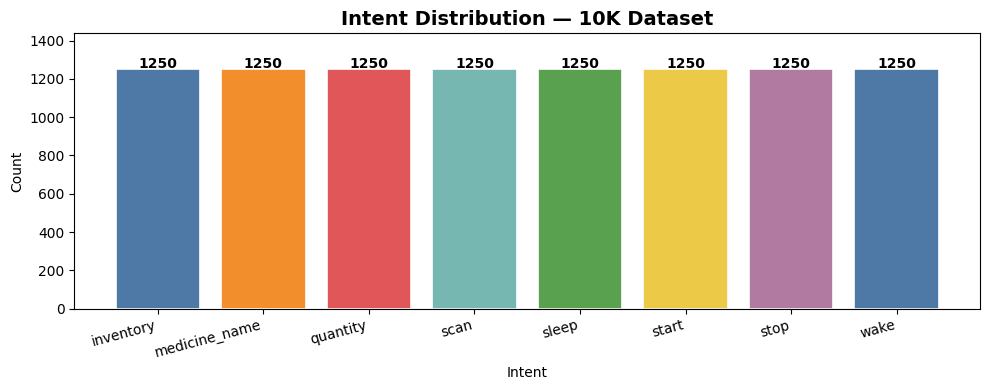

In [16]:
# تحميل البيانات
df = pd.read_csv('therapeia_intent_dataset_10k.csv')

# عرض معلومات سريعة عن البيانات
print(f'Shape  : {df.shape}')
print(f'Intents: {sorted(df.intent.unique())}')
print()
print(df.intent.value_counts())
print()
print(df.sample(12, random_state=1).to_string(index=False))

# ── إعداد لوحة الألوان (المشكلة كانت هنا) ──────────────────────────────────────────
# يمكنك اختيار قائمة ألوان أو استخدام Tab20 للتنوع
PALETTE = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#EDC948', '#B07AA1']

# ── رسم المخطط البياني (Distribution bar chart) ─────────────────────────────────
plt.figure(figsize=(10, 4))
counts = df.intent.value_counts().sort_index()

# استخدام المتغير PALETTE بعد تعريفه
bars = plt.bar(counts.index, counts.values, color=PALETTE[:len(counts)], edgecolor='white', linewidth=1.2)

# إضافة الأرقام فوق الأعمدة
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(v),
             ha='center', fontweight='bold', fontsize=10)

plt.title('Intent Distribution — 10K Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()

# حفظ وعرض الشكل
plt.show()

══════════════════════════════════════════════════
  Shape         : (10000, 2)
  Missing values: {'text': 0, 'intent': 0}
  Duplicates    : 0
══════════════════════════════════════════════════
  Arabic rows   : 3830  (38.3%)
  English rows  : 6464  (64.6%)
  Mixed rows    : 294
══════════════════════════════════════════════════


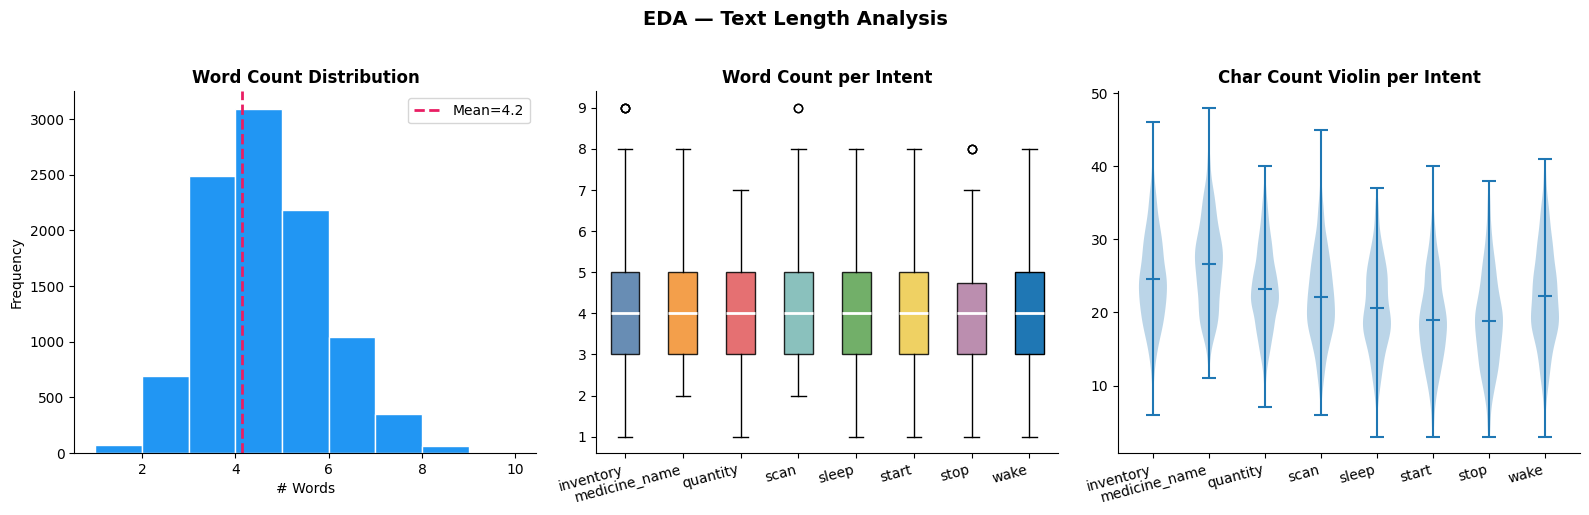

In [17]:
# ══════════════════════════════════════════════════════════
#  EDA — Exploratory Data Analysis
# ══════════════════════════════════════════════════════════

INTENT_COLORS = dict(zip(sorted(df['intent'].unique()), PALETTE))

# ── 1. Missing / duplicates ───────────────────────────────
print('═'*50)
print(f'  Shape         : {df.shape}')
print(f'  Missing values: {df.isnull().sum().to_dict()}')
print(f'  Duplicates    : {df.duplicated().sum()}')
print('═'*50)

# ── 2. Language distribution ──────────────────────────────
ar_mask = df['text'].str.contains('[ء-ي]', regex=True, na=False)
en_mask = df['text'].str.contains('[a-zA-Z]', regex=True, na=False)
print(f'  Arabic rows   : {ar_mask.sum()}  ({ar_mask.mean():.1%})')
print(f'  English rows  : {en_mask.sum()}  ({en_mask.mean():.1%})')
print(f'  Mixed rows    : {(ar_mask & en_mask).sum()}')
print('═'*50)

# ── 3. Text-length analysis ───────────────────────────────
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['word_count'], bins=range(1, df['word_count'].max()+2),
             color='#2196F3', edgecolor='white', linewidth=1)
axes[0].axvline(df['word_count'].mean(), color='#E91E63', linestyle='--',
                linewidth=2, label=f'Mean={df["word_count"].mean():.1f}')
axes[0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('# Words'); axes[0].set_ylabel('Frequency')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

intents_sorted = sorted(df['intent'].unique())
data_wc = [df[df['intent']==i]['word_count'].values for i in intents_sorted]
bp = axes[1].boxplot(data_wc, labels=intents_sorted, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[1].set_title('Word Count per Intent', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(intents_sorted, rotation=15, ha='right')
axes[1].spines[['top','right']].set_visible(False)

axes[2].violinplot([df[df['intent']==i]['char_count'].values for i in intents_sorted],
                   showmeans=True)
axes[2].set_xticks(range(1, len(intents_sorted)+1))
axes[2].set_xticklabels(intents_sorted, rotation=15, ha='right')
axes[2].set_title('Char Count Violin per Intent', fontsize=12, fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('EDA — Text Length Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
print('⏳ Training TextCNN...')

# تسجيل وقت البداية
t0 = time.time()

# 1. استدعاء دالة التدريب (تم حذف name='TextCNN' لأن الدالة لا تقبله)
cnn_history = train_model(
    cnn_model, 
    train_dl, 
    val_dl, 
    epochs=35
)

# حساب وعرض الوقت المستغرق
duration = time.time() - t0
print(f'✅ Finished in {duration:.1f}s')

⏳ Training TextCNN...
  Ep 05/35 | train_acc=0.994  val_acc=0.990
  Early stop at epoch 8
✅ Finished in 15.3s


## Cell 15 — `predict_intent()` — الـ Function اللي هتُستخدم في 03

In [19]:
# ── هذه الـ cell هي المرجع للـ voice controller ─────────────────────────────
# نسخها للـ 03_voice_controller.ipynb أو import منها مباشرةً

def load_intent_model(model_type='cnn'):
    """تحميل النموذج المحفوظ."""
    with open('models/nlp_meta.json') as f:
        meta = json.load(f)

    w2i    = meta['word2idx']
    labels = meta['intent_names']
    mlen   = meta['max_len']
    nclass = meta['num_classes']

    if model_type == 'cnn':
        m = TextCNN(len(w2i), num_classes=nclass)
        m.load_state_dict(torch.load('models/intent_cnn.pt', map_location='cpu'))
    elif model_type == 'lstm':
        m = BiLSTM(len(w2i), num_classes=nclass)
        m.load_state_dict(torch.load('models/intent_lstm.pt', map_location='cpu'))
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    m.eval()
    return m, w2i, labels, mlen


def predict_intent(text: str, model, word2idx,
                   intent_names, max_len=MAX_LEN,
                   threshold=0.50):
    """
    يستبدل keyword matching في voice controller.
    Returns: (intent_str, confidence_float)
    """
    # Preprocess
    text  = re.sub(r"[^a-z0-9\s'\u0600-\u06FF]", ' ', text.lower())
    text  = re.sub(r'\s+', ' ', text).strip()

    # Encode
    ids = [word2idx.get(w, 1) for w in text.split()][:max_len]
    ids += [0] * (max_len - len(ids))
    x   = torch.tensor([ids], dtype=torch.long)

    # Infer
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]

    top_conf = probs.max().item()
    top_idx  = probs.argmax().item()

    if top_conf < threshold:
        return 'unknown', top_conf

    return intent_names[top_idx], top_conf


# ── Test ─────────────────────────────────────────────────────────────────────
print('Testing predict_intent() ...')
_m, _w2i, _labels, _mlen = load_intent_model('cnn')

for test_phrase in [
    'therapeia wake up',
    'scan the medicine now',
    'let\'s start',
    'stop please',
    'go to sleep',
    'how many brufen',
    'show me the inventory',
    'ketofan',
]:
    intent, conf = predict_intent(test_phrase, _m, _w2i, _labels, _mlen)
    print(f'  "{test_phrase:<30}" → {intent:<14} ({conf:.2%})')

Testing predict_intent() ...
  "therapeia wake up             " → wake           (99.99%)
  "scan the medicine now         " → scan           (100.00%)
  "let's start                   " → start          (99.97%)
  "stop please                   " → stop           (100.00%)
  "go to sleep                   " → sleep          (99.96%)
  "how many brufen               " → quantity       (99.99%)
  "show me the inventory         " → inventory      (99.99%)
  "ketofan                       " → unknown        (22.99%)
